# Notebook 04 — Topic Modeling + Correlation Analysis
**Owner:** Nataly Jimenez

**Inputs:**
- `../data/processed/sentiment_weekly.csv` (from Notebook 03)
- `../data/prices/prices_clean.csv` (from Notebook 01)
- `../data/reddit/reddit_raw.csv` (for LDA text corpus)

**Goal:**
1. Run LDA topic modeling on Reddit posts — identify dominant topics during price spikes vs. stable periods
2. Correlate weekly sentiment with hardware prices (including lagged correlation)
3. Produce final visualizations for the report

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# ── Output dir ────────────────────────────────────────────────────────────────
import os
OUT = "../data/topic-modeling"
os.makedirs(OUT, exist_ok=True)

## 0. Load All Data

In [2]:
df_sentiment = pd.read_csv("../data/processed/sentiment_weekly.csv")
df_prices    = pd.read_csv("../data/prices/prices_clean.csv", parse_dates=["date"])
df_reddit    = pd.read_csv("../data/reddit/reddit_raw.csv", parse_dates=["date"])
# todo: run functions to obtain these csv's if running ntoebook4 first
print("Sentiment Dataframe: \n")
display(df_sentiment.head())
print(df_sentiment.shape)
print("Prices: \n" )
display(df_prices.head())
print("Prices Dataframe Date Range: ", df_prices['date'].min(), "to", df_prices['date'].max(), "\n")
print(df_prices.shape)
print("Reddit Posts:")
display(df_reddit.head())
print("Reddit Dataframe Date Range: ", df_reddit['date'].min(), "to", df_reddit['date'].max())
print(df_reddit.shape)

Sentiment Dataframe: 



,week,subreddit,avg_sentiment,post_count,avg_upvotes
0,2024-09-30/2024-10-06,hardware,0.063600,2,1.0
1,2024-10-07/2024-10-13,hardware,-0.094712,8,1.0
2,2024-10-14/2024-10-20,hardware,0.980650,2,1.0
3,2024-10-21/2024-10-27,hardware,0.998600,1,1.0
4,2024-10-28/2024-11-03,hardware,0.428067,6,1.0


(80, 5)
Prices: 



,date,product,category,price_usd,retailer,url
0,2024-04-29,"AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked De...",CPU,93.98,B&H Photo Video,https://pangoly.com/en/product/amd-ryzen-5-5500
1,2024-04-29,"AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked De...",CPU,94.00,BestBuy,https://pangoly.com/en/product/amd-ryzen-5-5500
2,2024-04-29,"AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked De...",CPU,159.00,GameStop,https://pangoly.com/en/product/amd-ryzen-5-5500
3,2024-04-29,"AMD Ryzen 5 5500 6-Core, 12-Thread Unlocked De...",CPU,93.98,Newegg,https://pangoly.com/en/product/amd-ryzen-5-5500
4,2024-04-29,"AMD Ryzen 5 5600 6-Core, 12-Thread Unlocked De...",CPU,207.50,Adorama,https://pangoly.com/en/product/amd-ryzen-5-5600


Prices Dataframe Date Range:  2024-04-29 00:00:00 to 2026-04-27 00:00:00 

(6549, 6)
Reddit Posts:


,post_id,date,subreddit,title,body,top_comments,upvotes,url
0,1kq5v8d,2025-05-19,buildapc,Help me upgrade my sisters PC,My sister made the very humble wish for her bi...,NaN,1,https://reddit.com/r/buildapc/comments/1kq5v8d...
1,1kq5uo9,2025-05-19,buildapc,Is Corsair CX 550 ( 2023 VERSION ) a good qual...,"Hello, I have a few questions regarding this p...",It's a D tier on the SPL tier list. D criter...,1,https://reddit.com/r/buildapc/comments/1kq5uo9...
2,1kq0tku,2025-05-19,buildapc,gpu for 1080p gaming $600 price range,"I'm looking to upgrade my GPU, a 1080 Ti that'...",You don't need to spend anywhere near $600 for...,1,https://reddit.com/r/buildapc/comments/1kq0tku...
3,1kpqqi6,2025-05-18,buildapc,Are these two builds comparable to a better-tr...,"To preface, I don't need a PC that can stream ...",They aren't equal. But one is not worth over $...,1,https://reddit.com/r/buildapc/comments/1kpqqi6...
4,1kpqa83,2025-05-18,buildapc,[Build Review] 7950X + RTX 4070 Ti SUPER white...,Goal \n\n* Heavy computational fluid dynamics...,Don't buy an RTX 4070 Ti Super. They haven't b...,1,https://reddit.com/r/buildapc/comments/1kpqa83...


Reddit Dataframe Date Range:  2024-10-04 00:00:00 to 2025-05-19 00:00:00
(2377, 8)


## 1. Prepare Weekly Price Index
### 1a. Filter prices dataframe to overlapping date range

In [3]:
OVERLAP_START = max(df_prices["date"].min(), df_reddit["date"].min())
OVERLAP_END = min(df_prices["date"].max(), df_reddit["date"].max())
print(f"Price range  : {df_prices['date'].min().date()} to {df_prices['date'].max().date()}")
print(f"Reddit range : {df_reddit['date'].min().date()} to {df_reddit['date'].max().date()}")
print(f"Overlap      : {OVERLAP_START.date()} to {OVERLAP_END.date()}")

Price range  : 2024-04-29 to 2026-04-27
Reddit range : 2024-10-04 to 2025-05-19
Overlap      : 2024-10-04 to 2025-05-19


In [4]:
prices_overlap = df_prices[
    (df_prices["date"] >= OVERLAP_START) & (df_prices["date"] <= OVERLAP_END)
].copy()

### 1b. Aggregate Weekly Price

In [5]:
# convert each date into a week
prices_overlap["week"] = prices_overlap["date"].dt.to_period("W").astype(str)

# compute weekly averages per category
price_weekly = (
    prices_overlap.groupby(["week", "category"])["price_usd"]
    .mean()
    .reset_index()
    .rename(columns={"price_usd": "avg_price"})
)
price_weekly

,week,category,avg_price
0,2024-10-07/2024-10-13,CPU,284.814348
1,2024-10-07/2024-10-13,GPU,693.316667
2,2024-10-07/2024-10-13,RAM,78.735263
3,2024-10-14/2024-10-20,CPU,283.760833
4,2024-10-14/2024-10-20,GPU,720.936667
...,...,...,...
94,2025-05-12/2025-05-18,GPU,1428.561429
95,2025-05-12/2025-05-18,RAM,77.234000
96,2025-05-19/2025-05-25,CPU,319.351071
97,2025-05-19/2025-05-25,GPU,1045.284118


In [6]:
# compute overall price index (all categories combined)
price_index = (
    prices_overlap.groupby("week")["price_usd"]
    .mean()
    .reset_index()
    .rename(columns={"price_usd": "price_index"})
)

In [7]:
# convert week strings into timestamp for plotting
def week_str_to_ts(s):
    """'2024-10-07/2024-10-13' or pandas Period string to Monday timestamp."""
    try:
        return pd.Period(s, freq="W").to_timestamp()
    except Exception:
        return pd.to_datetime(s.split("/")[0])

price_index["week_dt"] = price_index["week"].apply(week_str_to_ts)
price_weekly["week_dt"] = price_weekly["week"].apply(week_str_to_ts)

In [8]:
display(price_index.head()) # shows what the avg price of all hardware combined this week
display(price_weekly.head()) # shows what was the avg price for each category per week

,week,price_index,week_dt
0,2024-10-07/2024-10-13,225.036667,2024-10-07
1,2024-10-14/2024-10-20,226.632174,2024-10-14
2,2024-10-21/2024-10-27,222.030652,2024-10-21
3,2024-10-28/2024-11-03,223.858478,2024-10-28
4,2024-11-04/2024-11-10,240.243878,2024-11-04


,week,category,avg_price,week_dt
0,2024-10-07/2024-10-13,CPU,284.814348,2024-10-07
1,2024-10-07/2024-10-13,GPU,693.316667,2024-10-07
2,2024-10-07/2024-10-13,RAM,78.735263,2024-10-07
3,2024-10-14/2024-10-20,CPU,283.760833,2024-10-14
4,2024-10-14/2024-10-20,GPU,720.936667,2024-10-14


## 3. Merging Sentiment with Price

In [9]:
# extracting ALL rows only - all subreddits into one overall sentiment value per week
sent_all = df_sentiment[df_sentiment["subreddit"] == "ALL"].copy()
sent_all["week_dt"] = sent_all["week"].apply(week_str_to_ts)

# restrict to overlap window
sent_all = sent_all[
    (sent_all["week_dt"] >= OVERLAP_START) & (sent_all["week_dt"] <= OVERLAP_END)
].sort_values("week_dt").reset_index(drop=True)

In [10]:
df_merged = sent_all.merge(price_index[["week", "price_index", "week_dt"]],
                           on="week", how="inner", suffixes=("", "_p"))
# resolve duplicate week_dt cols if any
if "week_dt_p" in df_merged.columns:
    df_merged["week_dt"] = df_merged["week_dt"].fillna(df_merged["week_dt_p"])
    df_merged.drop(columns=["week_dt_p"], inplace=True)

df_merged = df_merged.sort_values("week_dt").reset_index(drop=True)
print(f"\nMerged weeks available for analysis: {len(df_merged)}")
print(df_merged[["week", "avg_sentiment", "price_index"]].head())

# merge per-category prices
df_merged_cat = sent_all.merge(
    price_weekly[["week", "category", "avg_price", "week_dt"]],
    on="week", how="inner", suffixes=("", "_p")
)
if "week_dt_p" in df_merged_cat.columns:
    df_merged_cat["week_dt"] = df_merged_cat["week_dt"].fillna(df_merged_cat["week_dt_p"])
    df_merged_cat.drop(columns=["week_dt_p"], inplace=True)


Merged weeks available for analysis: 31
                    week  avg_sentiment  price_index
0  2024-10-07/2024-10-13      -0.094712   225.036667
1  2024-10-14/2024-10-20       0.980650   226.632174
2  2024-10-21/2024-10-27       0.998600   222.030652
3  2024-10-28/2024-11-03       0.428067   223.858478
4  2024-11-04/2024-11-10       0.516400   240.243878


# 4. Price Spike Classification
### 4a. Defining a spike week 
**State 1:** — Price is greater than mean + 1 std (Spike - unusually high prices)

**State 2:** — Price is less than mean + 1 std (Dip - unusually low prices)

**State 3:** — Otherwise (Stable)

In [11]:
# =============================================================================
# 5.  PRICE SPIKE CLASSIFICATION  (for LDA labeling)
# =============================================================================
# Define a "spike" week as one where the price index is >= 1 std above mean
mu    = df_merged["price_index"].mean() # typical price level
sigma = df_merged["price_index"].std() # how much prices vary
df_merged["price_regime"] = np.where(
    df_merged["price_index"] >= mu + sigma, "spike",
    np.where(df_merged["price_index"] <= mu - sigma, "dip", "stable")
)
print("\nWeeks per regime:")
print(df_merged["price_regime"].value_counts())
 
# Map regime back to reddit posts
regime_map = df_merged.set_index("week")["price_regime"].to_dict()
df_reddit_overlap = df_reddit[
    (df_reddit["date"] >= OVERLAP_START) & (df_reddit["date"] <= OVERLAP_END)
].copy()
df_reddit_overlap["week"] = df_reddit_overlap["date"].dt.to_period("W").astype(str)
df_reddit_overlap["price_regime"] = df_reddit_overlap["week"].map(regime_map).fillna("stable")


Weeks per regime:
price_regime
stable    24
spike      7
Name: count, dtype: int64


### 4b. Dual-Axis Timeline: Price + Sentiment

In [12]:
PALETTE = {
    "price":     "#e05c5c",
    "sentiment": "#4a90d9",
    "spike":     "#f5a623",
    "stable":    "#7ed321",
    "dip":       "#9b59b6",
}
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

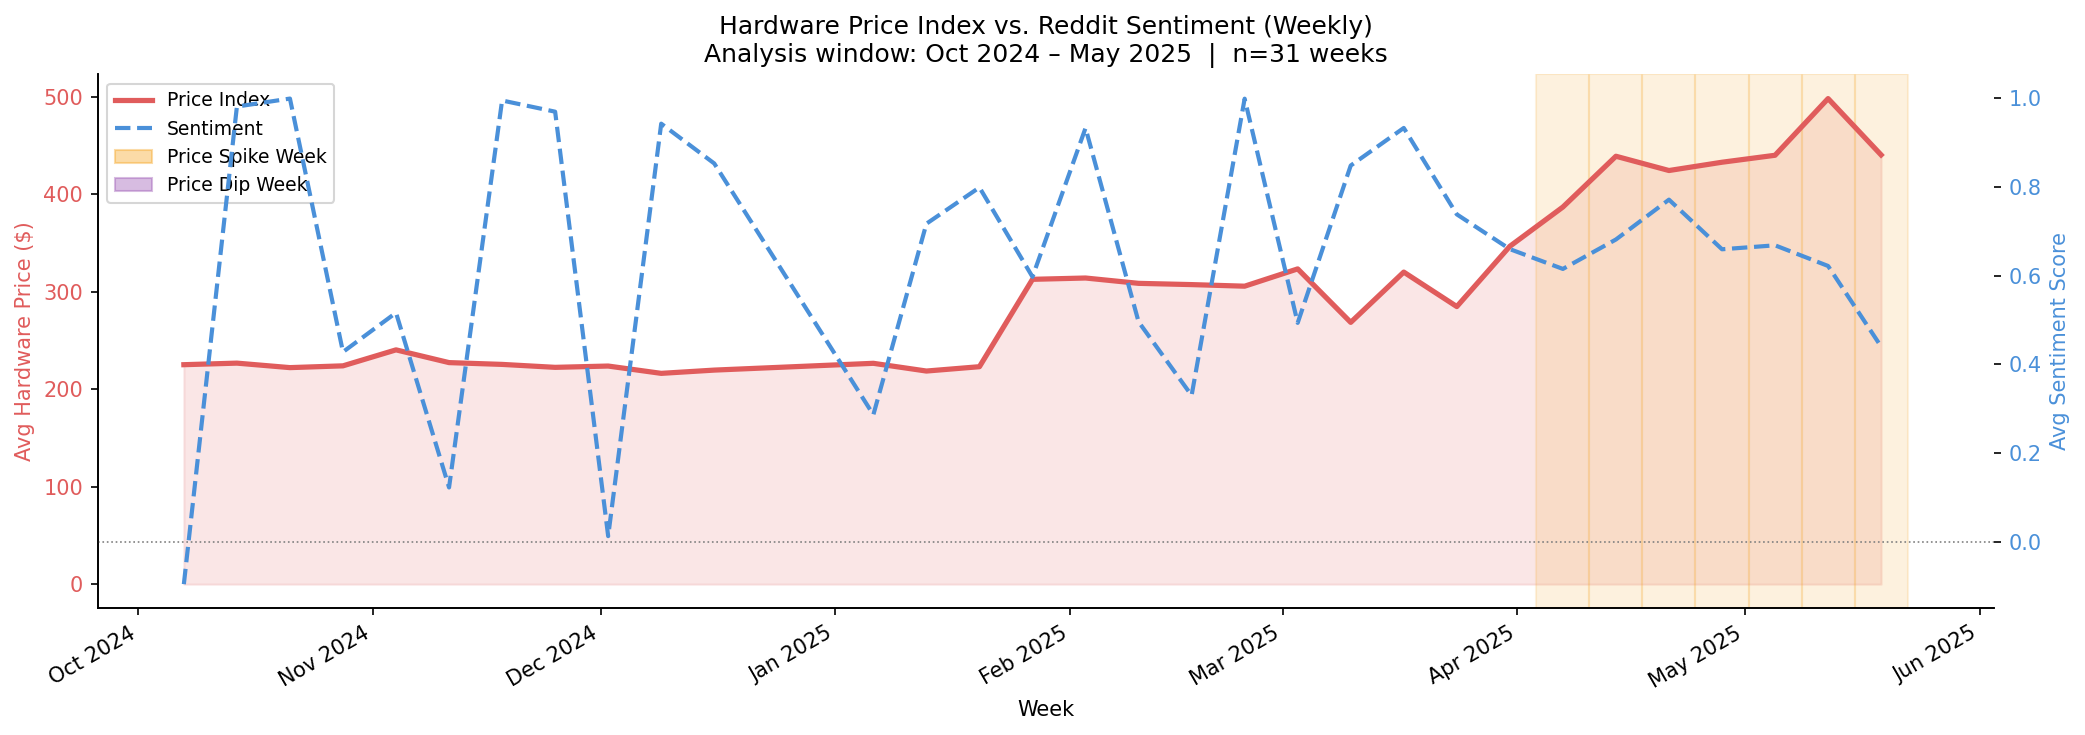

✓ Saved price_vs_sentiment.png


In [13]:
# ── Fig 1: Price Index vs. Sentiment (overlap window only) ───────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Week")
ax1.set_ylabel("Avg Hardware Price ($)", color=PALETTE["price"])
ax1.plot(df_merged["week_dt"], df_merged["price_index"],
         color=PALETTE["price"], linewidth=2.5, label="Price Index", zorder=3)
ax1.fill_between(df_merged["week_dt"], df_merged["price_index"],
                 alpha=0.15, color=PALETTE["price"])
ax1.tick_params(axis="y", labelcolor=PALETTE["price"])

# Shade spike / dip weeks
for _, row in df_merged.iterrows():
    if row["price_regime"] == "spike":
        ax1.axvspan(row["week_dt"] - pd.Timedelta("3.5d"),
                    row["week_dt"] + pd.Timedelta("3.5d"),
                    color=PALETTE["spike"], alpha=0.15, zorder=1)
    elif row["price_regime"] == "dip":
        ax1.axvspan(row["week_dt"] - pd.Timedelta("3.5d"),
                    row["week_dt"] + pd.Timedelta("3.5d"),
                    color=PALETTE["dip"], alpha=0.12, zorder=1)

ax2 = ax1.twinx()
ax2.set_ylabel("Avg Sentiment Score", color=PALETTE["sentiment"])
ax2.plot(df_merged["week_dt"], df_merged["avg_sentiment"],
         color=PALETTE["sentiment"], linewidth=2, linestyle="--",
         label="Sentiment", zorder=4)
ax2.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax2.tick_params(axis="y", labelcolor=PALETTE["sentiment"])

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()

# Legend
patch_spike  = mpatches.Patch(color=PALETTE["spike"],  alpha=0.4, label="Price Spike Week")
patch_dip    = mpatches.Patch(color=PALETTE["dip"],    alpha=0.4, label="Price Dip Week")
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + [patch_spike, patch_dip],
           lbl1 + lbl2 + ["Price Spike Week", "Price Dip Week"],
           loc="upper left", fontsize=9)

note = f"Analysis window: {OVERLAP_START.strftime('%b %Y')} – {OVERLAP_END.strftime('%b %Y')}  |  n={len(df_merged)} weeks"
plt.title(f"Hardware Price Index vs. Reddit Sentiment (Weekly)\n{note}", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT}/price_vs_sentiment.png", dpi=150)
plt.show()
print("✓ Saved price_vs_sentiment.png")


In [ ]:
# 1. Filter reddit posts to Apr–Jun 2025
mask = (df_reddit["date"] >= "2025-04-01") & (df_reddit["date"] <= "2025-06-30")
df_window = df_reddit[mask].copy()
# use llm method to find out what was happening during this time


## 5. Correlation Analysis
### 5a. Computing Pearson correlation for each lag
**Case 1:** — No lag (Do sentiment and price move together at the same time?)

**Case 2:** — Positive lag (sentiment leads price) (“Does sentiment predict future price?”)

**Case 3:** — Negative lag (sentiment lags price) (“Does sentiment react to price changes?”)


In [15]:
MAX_LAG = min(6, len(df_merged) // 3)   # sensible cap given ~7 months of data
lags = range(-MAX_LAG, MAX_LAG + 1)
 
corr_results = []
sent_vals  = df_merged["avg_sentiment"].values
price_vals = df_merged["price_index"].values

for lag in lags:
    if lag == 0:
        r_p, p_p = pearsonr(sent_vals, price_vals)
        r_s, p_s = spearmanr(sent_vals, price_vals)
    elif lag > 0:
        r_p, p_p = pearsonr(sent_vals[:-lag], price_vals[lag:])
        r_s, p_s = spearmanr(sent_vals[:-lag], price_vals[lag:])
    else:
        r_p, p_p = pearsonr(sent_vals[-lag:], price_vals[:lag])
        r_s, p_s = spearmanr(sent_vals[-lag:], price_vals[:lag])

    corr_results.append({
        "lag": lag,
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s
    })

corr_df = pd.DataFrame(corr_results)
best_pearson = corr_df.loc[corr_df["pearson_r"].abs().idxmax()]
best_spearman = corr_df.loc[corr_df["spearman_r"].abs().idxmax()]

print("Best Pearson lag:", best_pearson["lag"], best_pearson["pearson_r"])
print("Best Spearman lag:", best_spearman["lag"], best_spearman["spearman_r"])
 

Best Pearson lag: 5.0 0.20592872119216277
Best Spearman lag: 0.0 -0.2120967741935484


In [16]:
# per-category lagged correlation
cat_corr = {}
for cat in df_merged_cat["category"].unique():
    sub = df_merged_cat[df_merged_cat["category"] == cat].sort_values("week_dt")
    if len(sub) < 6:
        continue
    s_vals = sub["avg_sentiment"].values
    p_vals = sub["avg_price"].values
    rows = []
    for lag in lags:
        if lag == 0:
            r_p, p_p = pearsonr(s_vals, p_vals)
            r_s, p_s = spearmanr(s_vals, p_vals)
        elif lag > 0:
            if len(s_vals) <= lag:
                continue
            r_p, p_p = pearsonr(s_vals[:-lag], p_vals[lag:])
            r_s, p_s = spearmanr(s_vals[:-lag], p_vals[lag:])
        else:
            if len(s_vals) <= -lag:
                continue
            r_p, p_p = pearsonr(s_vals[-lag:], p_vals[:lag])
            r_s, p_s = spearmanr(s_vals[-lag:], p_vals[:lag])

        rows.append({
            "lag": lag,
            "pearson_r": r_p,
            "pearson_p": p_p,
            "spearman_r": r_s,
            "spearman_p": p_s
        })
    cat_corr[cat] = pd.DataFrame(rows)

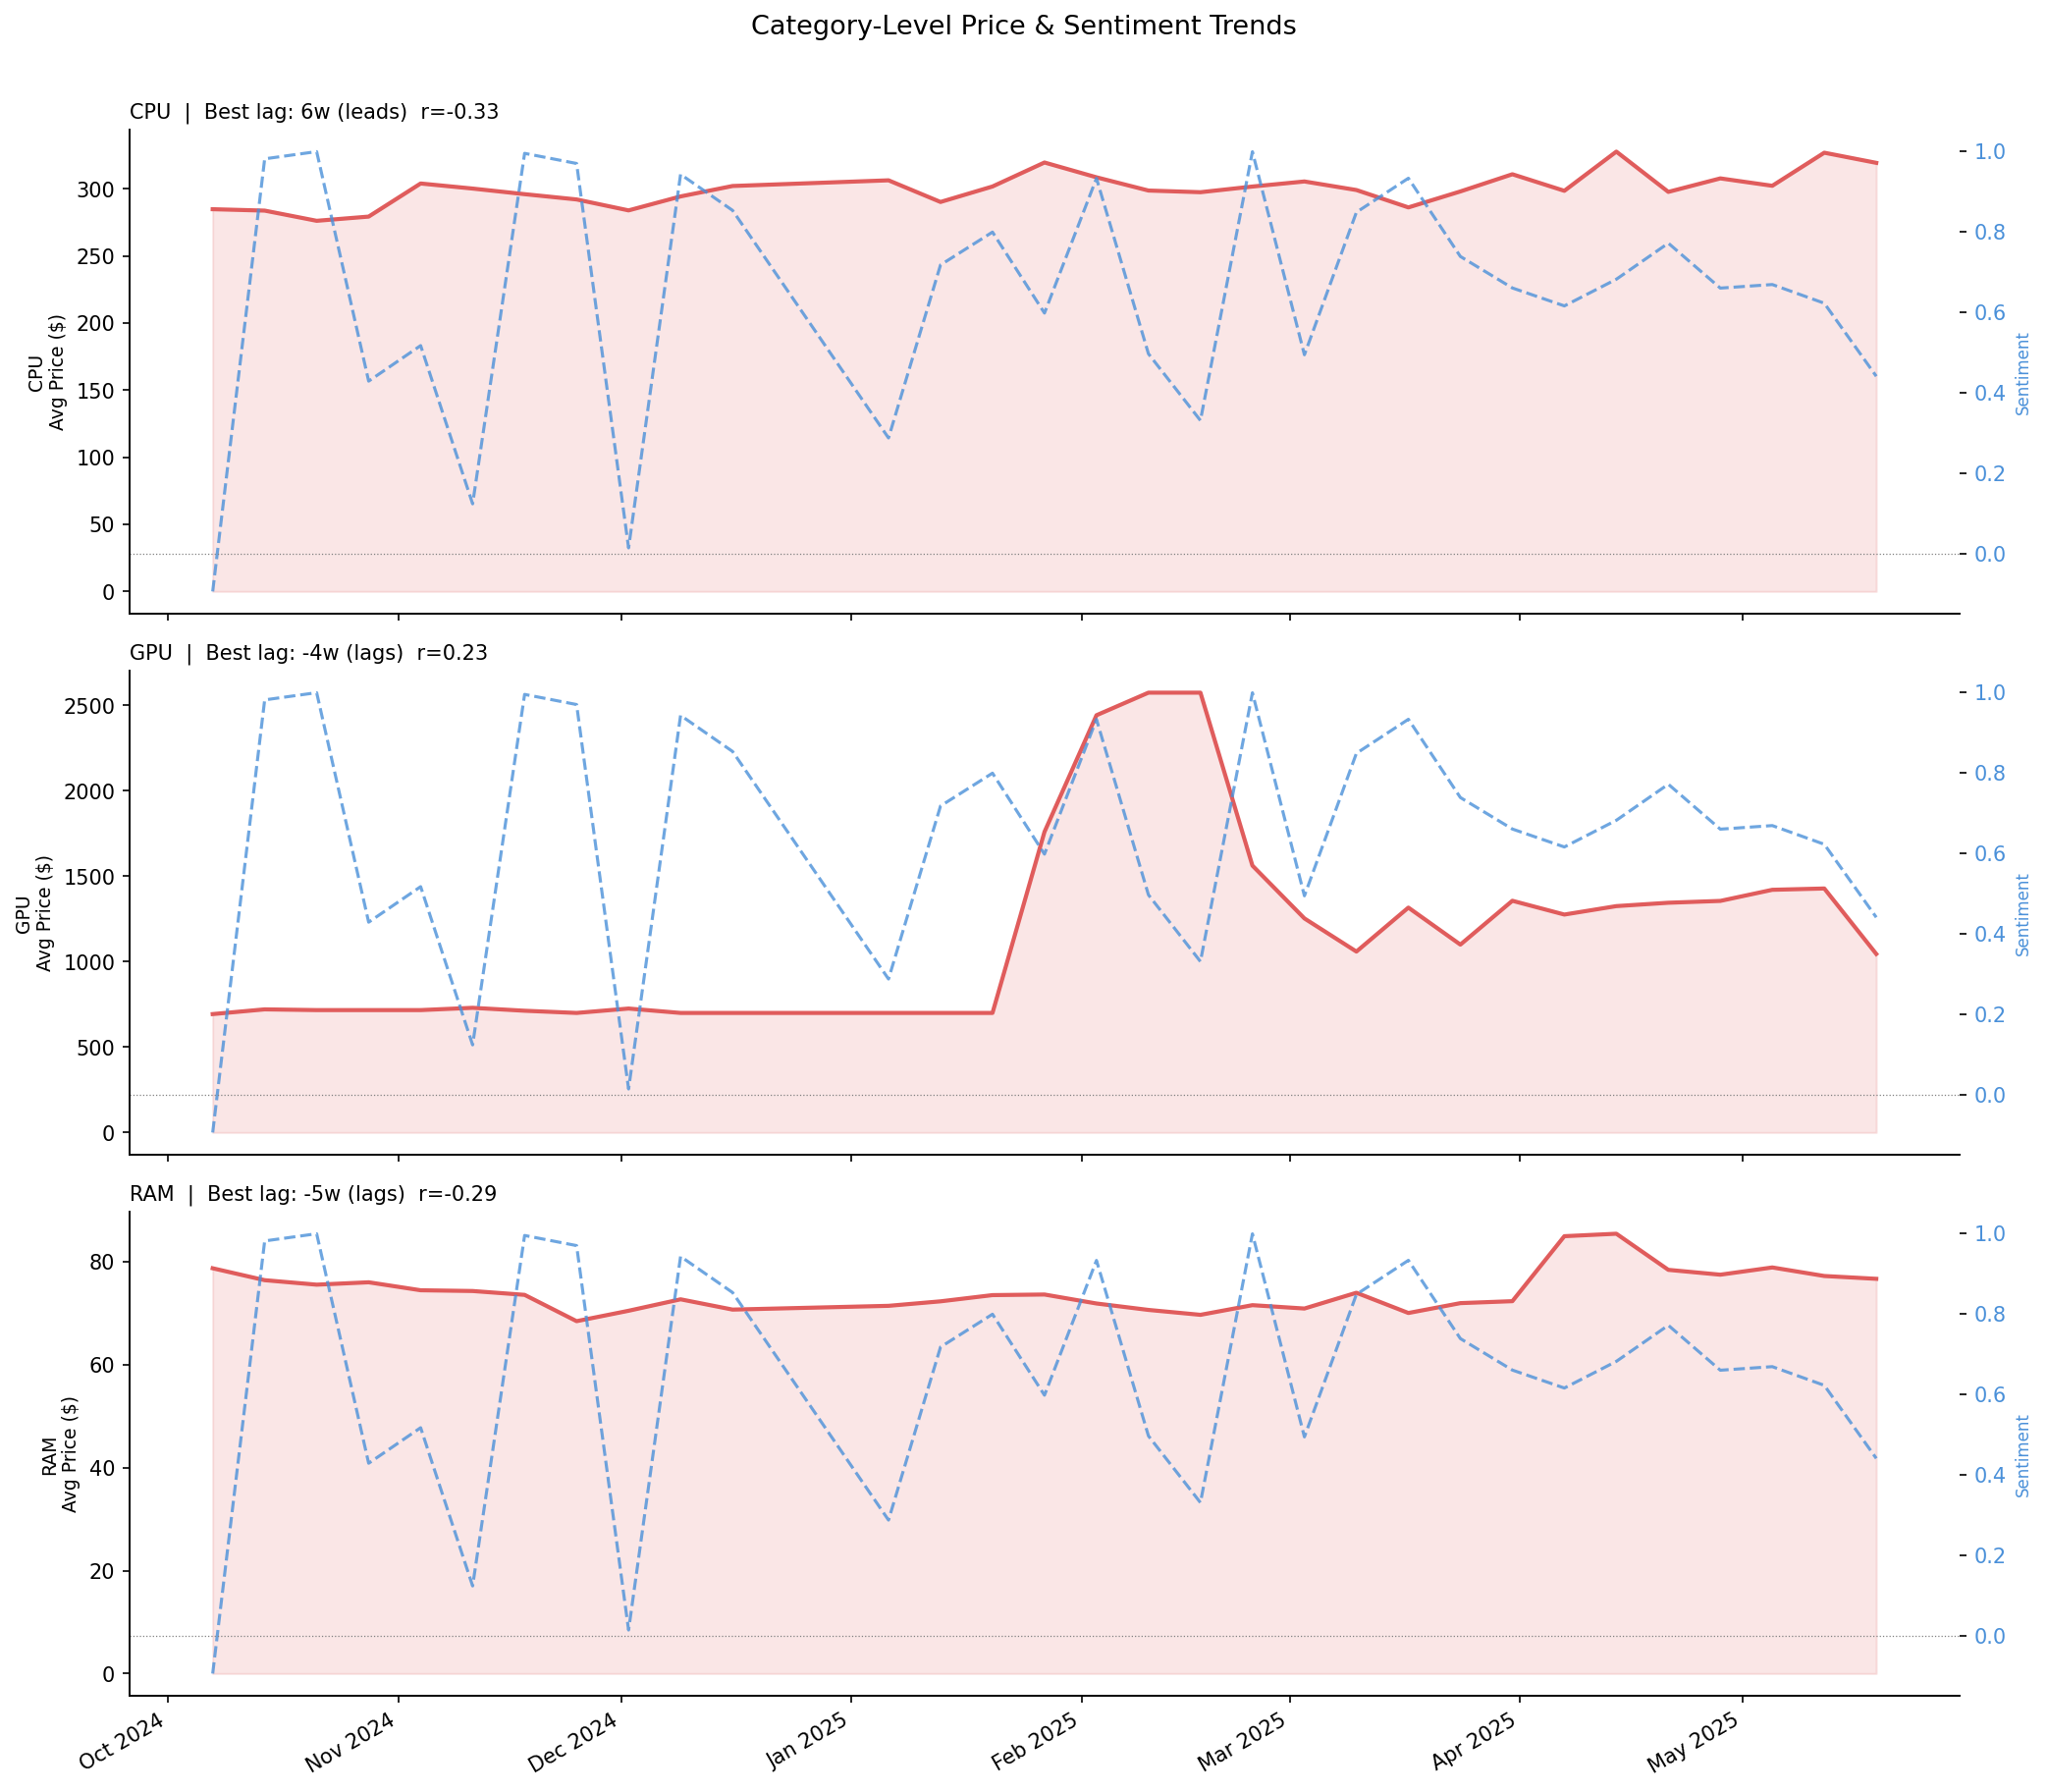

✓ Saved category_price_sentiment.png


In [17]:
# ── Fig 2: Per-Category Price Trends + Overall Sentiment ─────────────────────
cats = df_merged_cat["category"].unique()
fig, axes = plt.subplots(len(cats), 1, figsize=(14, 4 * len(cats)), sharex=True)
if len(cats) == 1:
    axes = [axes]
 
for ax, cat in zip(axes, cats):
    sub = df_merged_cat[df_merged_cat["category"] == cat].sort_values("week_dt")
    ax.plot(sub["week_dt"], sub["avg_price"],
            color=PALETTE["price"], linewidth=2, label=f"{cat} Price")
    ax.fill_between(sub["week_dt"], sub["avg_price"], alpha=0.15, color=PALETTE["price"])
    ax.set_ylabel(f"{cat}\nAvg Price ($)", fontsize=9)
 
    ax2c = ax.twinx()
    ax2c.plot(sub["week_dt"], sub["avg_sentiment"],
              color=PALETTE["sentiment"], linewidth=1.5, linestyle="--",
              alpha=0.8, label="Sentiment")
    ax2c.axhline(0, color="gray", linestyle=":", linewidth=0.6)
    ax2c.set_ylabel("Sentiment", color=PALETTE["sentiment"], fontsize=8)
    ax2c.tick_params(axis="y", labelcolor=PALETTE["sentiment"])
 
    # Annotate best lag for this category
    if cat in cat_corr and len(cat_corr[cat]) > 0:
        b = cat_corr[cat].loc[cat_corr[cat]["pearson_r"].abs().idxmax()]
        sign = "leads" if b["lag"] > 0 else ("lags" if b["lag"] < 0 else "concurrent")
        ax.set_title(f"{cat}  |  Best lag: {int(b['lag'])}w ({sign})  r={b['pearson_r']:.2f}",
                     fontsize=10, loc="left")
 
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.suptitle("Category-Level Price & Sentiment Trends", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT}/category_price_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved category_price_sentiment.png")

### 5b. Lagged Correlation — Does sentiment predict future price (or vice versa)?

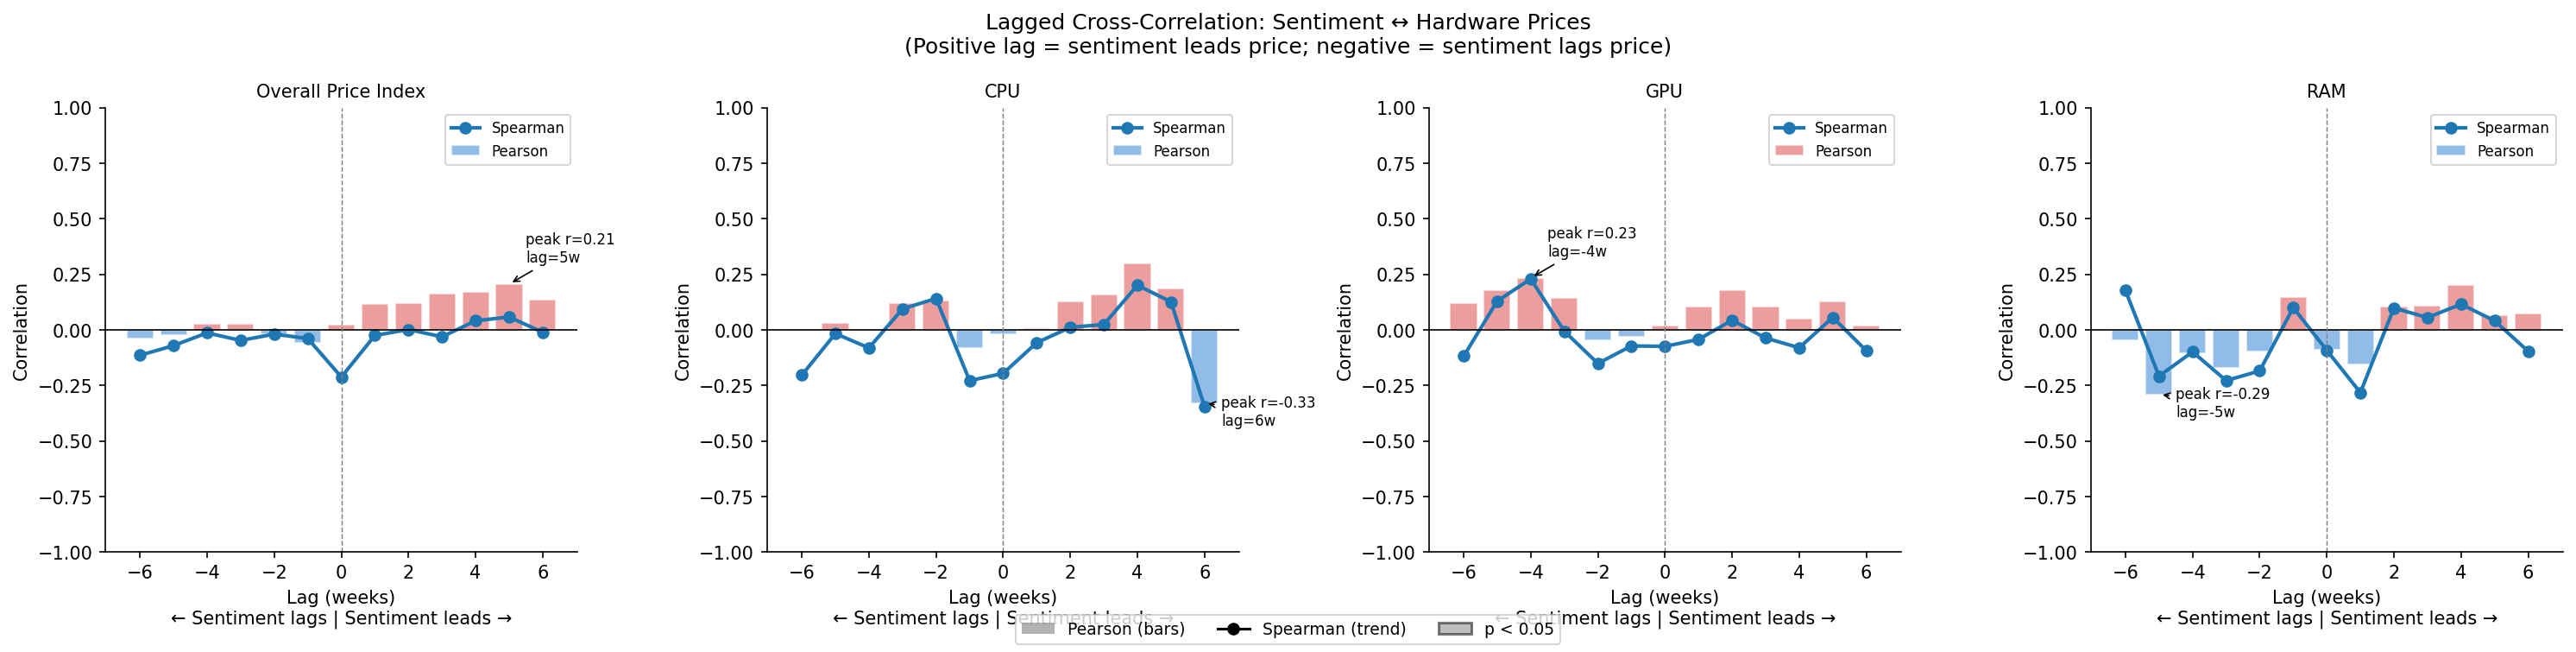

✓ Saved lagged_correlation.png


In [18]:
# ── Fig 3: Lagged Correlation Bar Chart ─────────────────────────────────────
fig, axes = plt.subplots(1, len(cats) + 1, figsize=(5 * (len(cats) + 1), 5), sharey=False)
 
def plot_lag_corr(ax, df_corr, title):
    # Bars = Pearson
    colors = [PALETTE["price"] if r > 0 else PALETTE["sentiment"]
              for r in df_corr["pearson_r"]]
    
    bars = ax.bar(df_corr["lag"], df_corr["pearson_r"],
                  color=colors, alpha=0.6, edgecolor="white", label="Pearson")

    # Significant Pearson bars
    sig_mask = df_corr["pearson_p"] < 0.05
    for bar, sig in zip(bars, sig_mask):
        if sig:
            bar.set_edgecolor("black")
            bar.set_linewidth(1.5)

    # Spearman as line
    ax.plot(df_corr["lag"], df_corr["spearman_r"],
            marker="o", linestyle="-", linewidth=2, label="Spearman")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.7)

    ax.set_xlabel("Lag (weeks)\n← Sentiment lags | Sentiment leads →")
    ax.set_ylabel("Correlation")
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-1, 1)

    # Best lag (based on Pearson, or you can choose Spearman)
    best = df_corr.loc[df_corr["pearson_r"].abs().idxmax()]
    ax.annotate(f"peak r={best['pearson_r']:.2f}\nlag={int(best['lag'])}w",
                xy=(best["lag"], best["pearson_r"]),
                xytext=(best["lag"] + 0.5, best["pearson_r"] + 0.1 * np.sign(best["pearson_r"])),
                fontsize=8,
                arrowprops=dict(arrowstyle="->", lw=0.8))

    ax.legend(fontsize=8)
plot_lag_corr(axes[0], corr_df, "Overall Price Index")
for i, cat in enumerate(cats):
    if cat in cat_corr:
        plot_lag_corr(axes[i + 1], cat_corr[cat], cat)
 
sig_patch = mpatches.Patch(edgecolor="black", facecolor="gray",
                            alpha=0.5, linewidth=1.5, label="p < 0.05")
pearson_patch = mpatches.Patch(facecolor="gray", alpha=0.6, label="Pearson (bars)")
spearman_line = mlines.Line2D([], [], color="black", marker="o",
                              linestyle="-", label="Spearman (trend)")

fig.legend(handles=[pearson_patch, spearman_line, sig_patch],
           loc="lower center", ncol=3, fontsize=9)
plt.suptitle("Lagged Cross-Correlation: Sentiment ↔ Hardware Prices\n"
             "(Positive lag = sentiment leads price; negative = sentiment lags price)",
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT}/lagged_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved lagged_correlation.png")

## 6. LDA Topic Modeling
### 6a. Fit LDA on all posts

In [19]:
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
 
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
 

True

In [ ]:
STOP_WORDS = set(stopwords.words("english"))
STOP_WORDS |= {
    # Reddit / generic noise
    "like","just","get","got","one","use","using","used","want","want",
    "need","know","think","going","would","could","also","really","make",
    "even","see","well","much","many","still","good","way","thanks","help",
    "anyone","anyone","something","anything","everything","nothing","people",
    "post","reddit","comment","https","www","com","http","amp","gt","lt",
    # hardware filler
    "build","pc","computer","system","new","old","buy","buying","bought",
}
lemmatizer = WordNetLemmatizer()
 
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)      # URLs
    text = re.sub(r"[^a-z\s]", " ", text)             # non-alpha
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [lemmatizer.lemmatize(t) for t in text.split()
              if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)
 
df_reddit_overlap["text"] = (
    df_reddit_overlap["title"].fillna("") + " " +
    df_reddit_overlap["body"].fillna("")
)
df_reddit_overlap["clean_text"] = df_reddit_overlap["text"].apply(clean_text)
df_reddit_overlap = df_reddit_overlap[df_reddit_overlap["clean_text"].str.len() > 10]
 

In [ ]:
N_TOPICS   = 8
N_TOP_WORDS = 10
 
vectorizer = CountVectorizer(
    max_df=0.90,       # ignore terms in >90 % of docs
    min_df=5,          # ignore terms in <5 docs
    max_features=4000,
    ngram_range=(1, 2),
)
dtm = vectorizer.fit_transform(df_reddit_overlap["clean_text"])
vocab = vectorizer.get_feature_names_out()
 
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method="online",
    learning_offset=50.0,
    doc_topic_prior=0.1,
    topic_word_prior=0.01,
)
lda.fit(dtm)
 
# Top words per topic
def get_top_words(model, feature_names, n=10):
    topics = {}
    for i, comp in enumerate(model.components_):
        top_idx = comp.argsort()[:-n-1:-1]
        topics[i] = [feature_names[j] for j in top_idx]
    return topics
 
topic_top_words = get_top_words(lda, vocab, N_TOP_WORDS)
 
# Assign dominant topic to each post
doc_topic_dist = lda.transform(dtm)
df_reddit_overlap["dominant_topic"] = doc_topic_dist.argmax(axis=1)
df_reddit_overlap["topic_prob"]     = doc_topic_dist.max(axis=1)
 
# Topic labels (manually interpret top words — edit as appropriate)
TOPIC_LABELS = {
    0: "GPU Performance & Gaming",
    1: "CPU Comparisons & Upgrades",
    2: "RAM / Memory Pricing",
    3: "Build Advice & Compatibility",
    4: "Benchmark & Reviews",
    5: "Deals & Price Alerts",
    6: "Cooling & Power Supply",
    7: "General Tech Discussion",
}
 
df_reddit_overlap["topic_label"] = df_reddit_overlap["dominant_topic"].map(TOPIC_LABELS)
 
# Topic share per price regime
regime_topic = (
    df_reddit_overlap.groupby(["price_regime", "dominant_topic"])
    .size()
    .reset_index(name="count")
)
regime_topic["topic_label"] = regime_topic["dominant_topic"].map(TOPIC_LABELS)
regime_topic_pct = regime_topic.copy()
totals = regime_topic_pct.groupby("price_regime")["count"].transform("sum")
regime_topic_pct["pct"] = regime_topic_pct["count"] / totals * 100
 
print("\nTop topic per regime:")
print(regime_topic_pct.sort_values(["price_regime","pct"], ascending=[True,False])
      .groupby("price_regime").head(3)[["price_regime","topic_label","pct"]])


Top topic per regime:
   price_regime              topic_label        pct
2         spike     RAM / Memory Pricing  44.479782
4         spike      Benchmark & Reviews  22.489777
7         spike  General Tech Discussion  16.992276
9        stable     RAM / Memory Pricing  69.005848
13       stable  General Tech Discussion  11.695906
10       stable      Benchmark & Reviews   5.847953


### 6b. Assign dominant topic per post + analyze topic distribution during price spikes

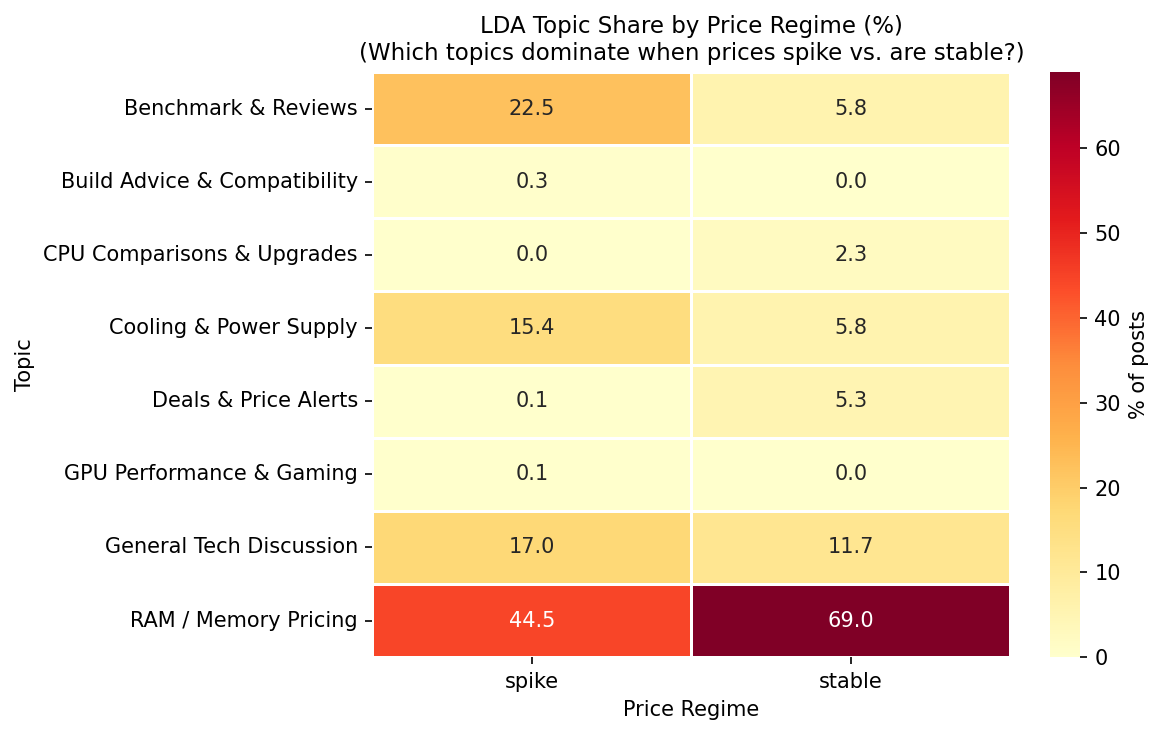

✓ Saved topic_regime_heatmap.png


In [25]:
# ── Fig 4: LDA Topic Heatmap (topic share by price regime) ───────────────────
pivot = regime_topic_pct.pivot_table(
    index="topic_label", columns="price_regime", values="pct", fill_value=0
)
# Reorder columns
col_order = [c for c in ["spike", "stable", "dip"] if c in pivot.columns]
pivot = pivot[col_order]
 
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "% of posts"})
ax.set_xlabel("Price Regime")
ax.set_ylabel("Topic")
ax.set_title("LDA Topic Share by Price Regime (%)\n"
             "(Which topics dominate when prices spike vs. are stable?)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT}/topic_regime_heatmap.png", dpi=150)
plt.show()
print("✓ Saved topic_regime_heatmap.png")

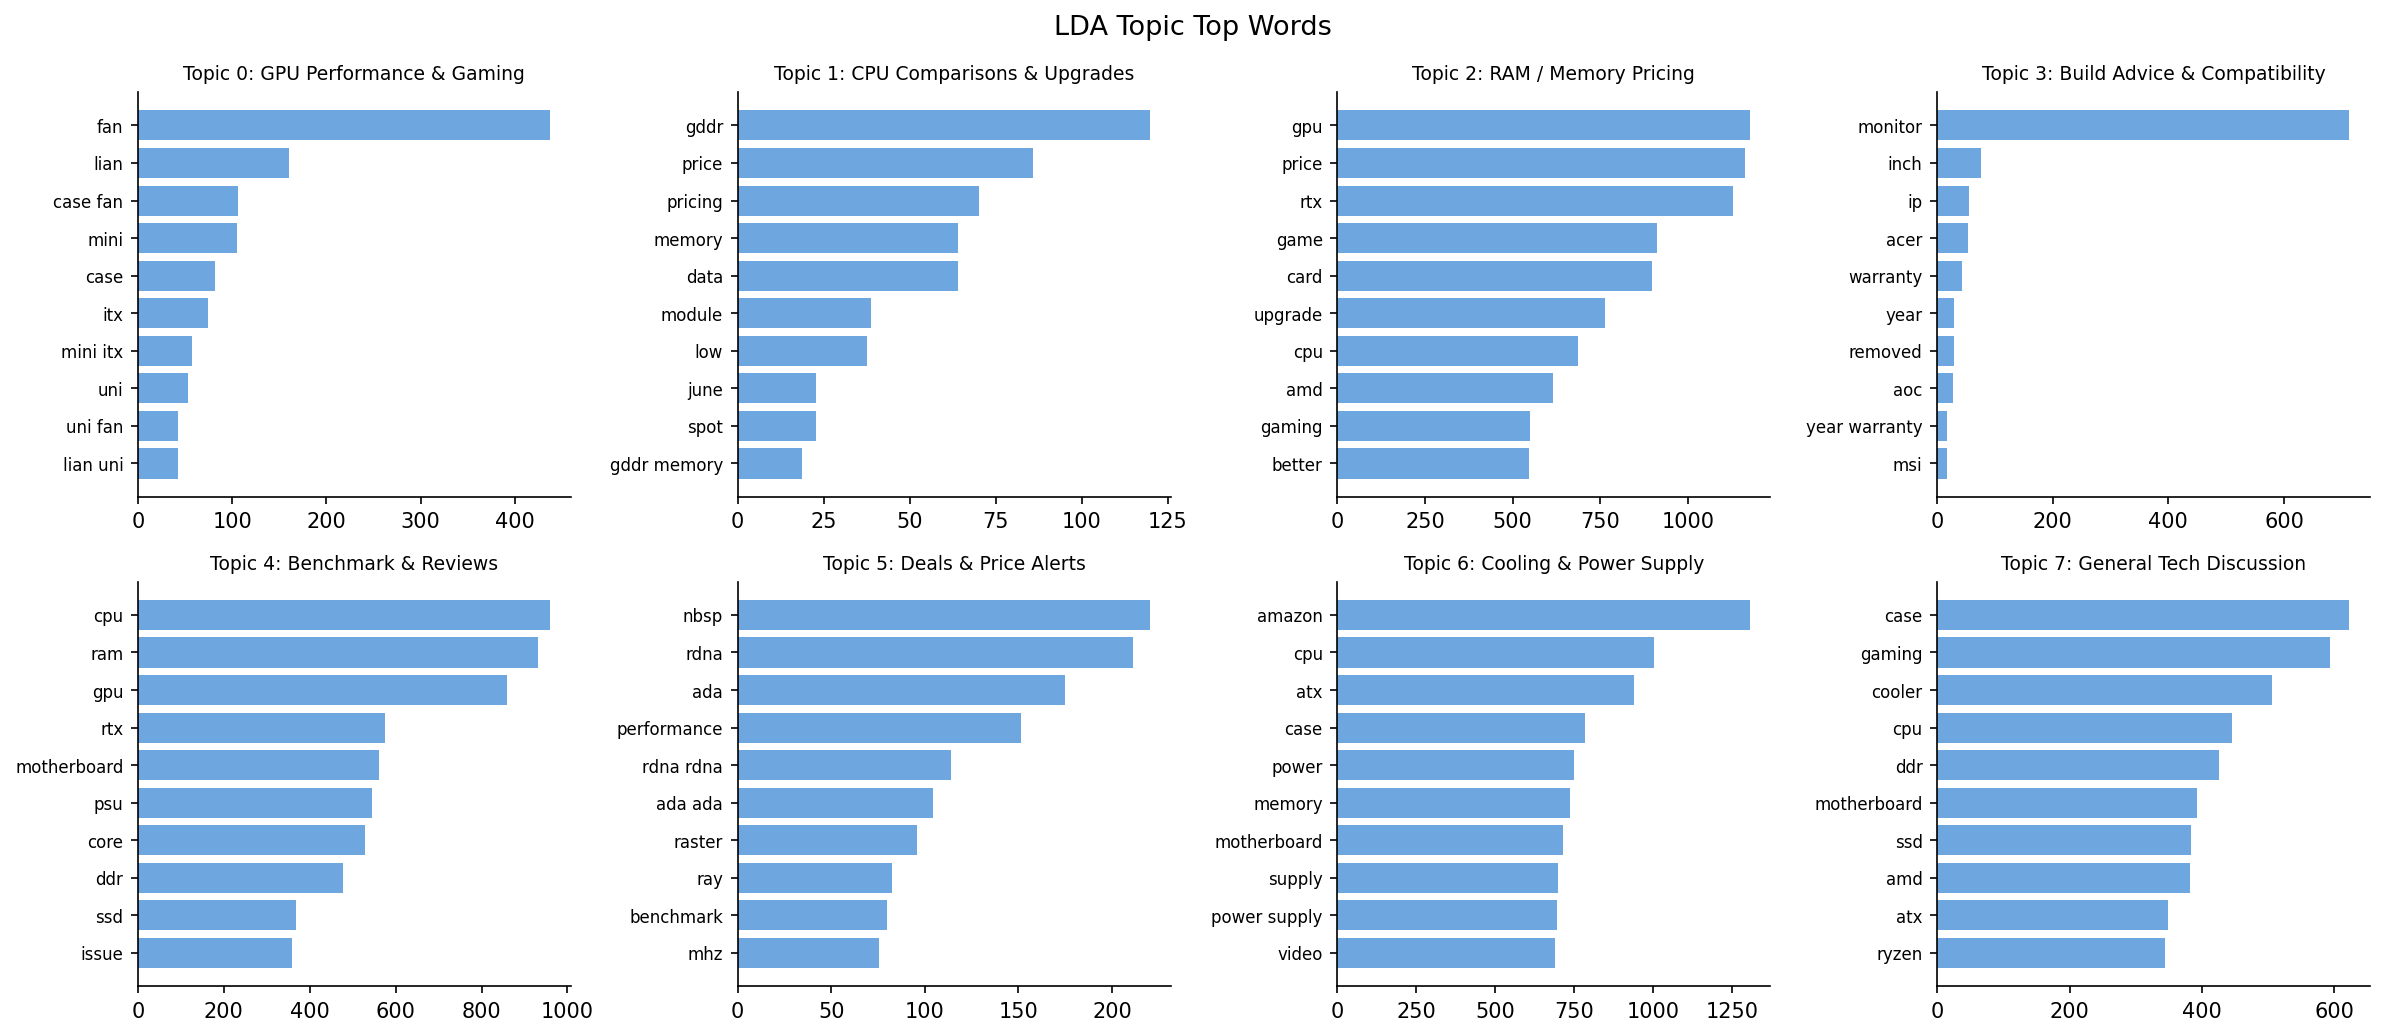

✓ Saved lda_top_words.png


In [26]:
# ── Fig 5: Top Words per Topic (horizontal bar) ───────────────────────────────
ncols = 4
nrows = (N_TOPICS + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()
 
for idx, (topic_id, words) in enumerate(topic_top_words.items()):
    ax = axes[idx]
    scores = lda.components_[topic_id][
        [np.where(vocab == w)[0][0] for w in words if w in vocab]
    ]
    ax.barh(words[::-1], scores[::-1], color=PALETTE["sentiment"], alpha=0.8)
    ax.set_title(f"Topic {topic_id}: {TOPIC_LABELS.get(topic_id,'')}", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
 
for ax in axes[N_TOPICS:]:
    ax.set_visible(False)
 
plt.suptitle("LDA Topic Top Words", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT}/lda_top_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved lda_top_words.png")

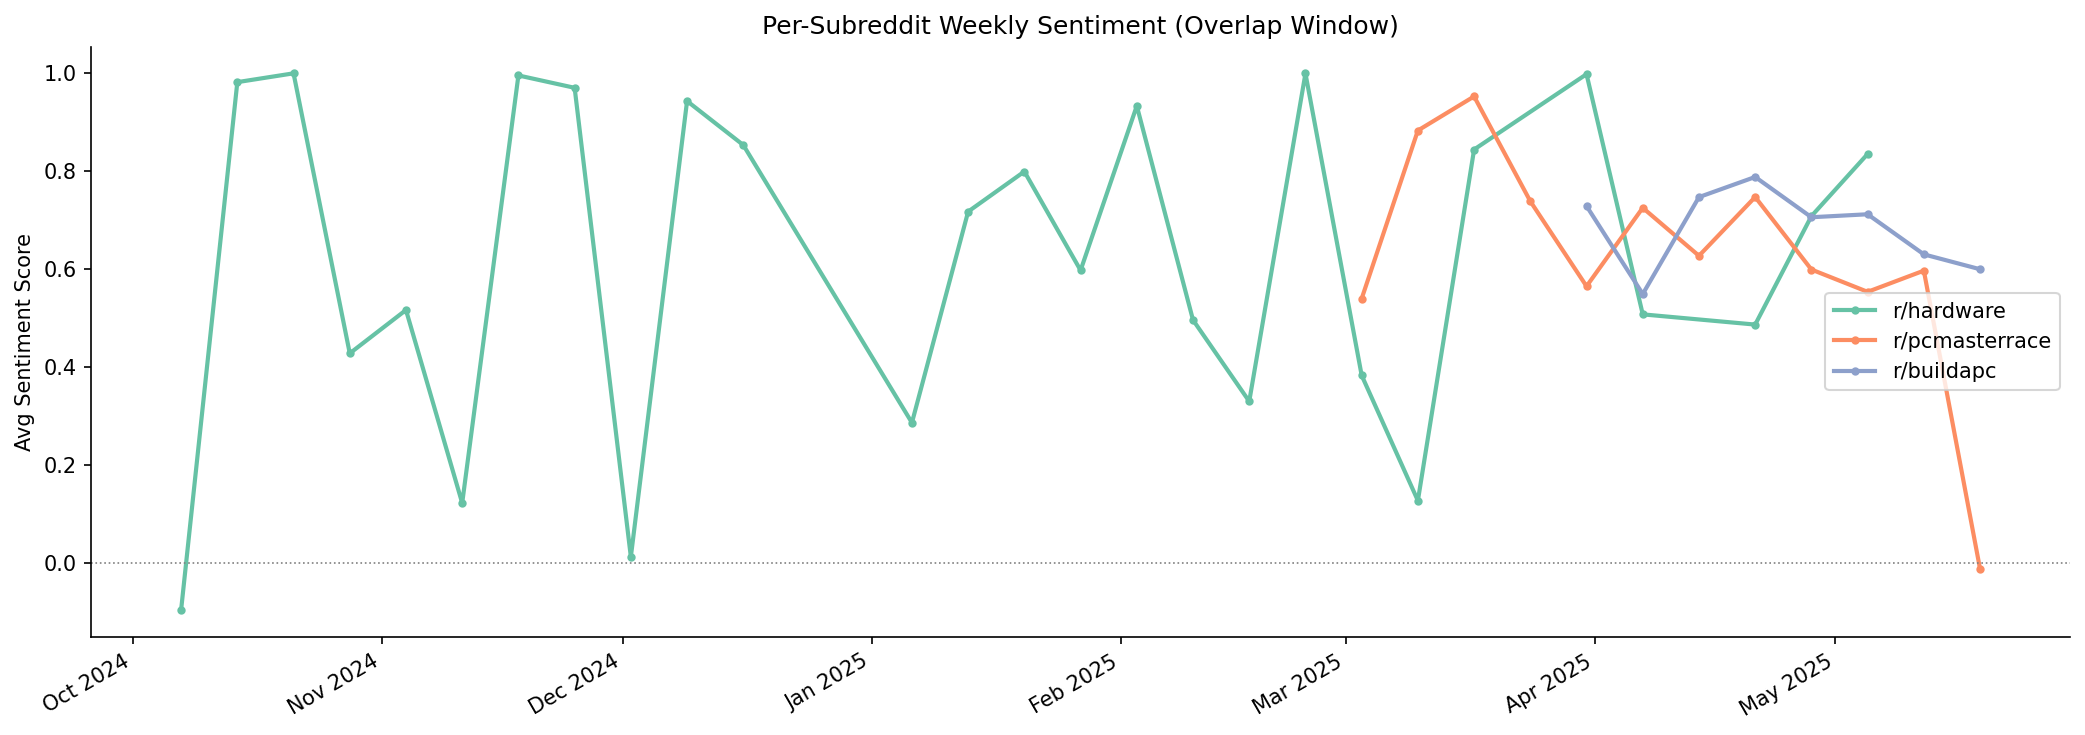

✓ Saved subreddit_sentiment_trends.png


In [27]:
# ── Fig 6: Per-subreddit sentiment over time ─────────────────────────────────
subs = [s for s in df_sentiment["subreddit"].unique() if s != "ALL"]
palette_sub = sns.color_palette("Set2", len(subs))
 
sent_sub = df_sentiment[df_sentiment["subreddit"].isin(subs)].copy()
sent_sub["week_dt"] = sent_sub["week"].apply(week_str_to_ts)
sent_sub = sent_sub[
    (sent_sub["week_dt"] >= OVERLAP_START) & (sent_sub["week_dt"] <= OVERLAP_END)
]
 
fig, ax = plt.subplots(figsize=(14, 5))
for sub, color in zip(subs, palette_sub):
    sub_data = sent_sub[sent_sub["subreddit"] == sub].sort_values("week_dt")
    ax.plot(sub_data["week_dt"], sub_data["avg_sentiment"],
            label=f"r/{sub}", linewidth=2, color=color, marker="o", markersize=3)
 
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
ax.legend(fontsize=10)
ax.set_ylabel("Avg Sentiment Score")
ax.set_title("Per-Subreddit Weekly Sentiment (Overlap Window)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT}/subreddit_sentiment_trends.png", dpi=150)
plt.show()
print("✓ Saved subreddit_sentiment_trends.png")

## 7. Summary of Findings

In [ ]:
summary = []
for cat, df_corr in cat_corr.items():
    if cat == "Overall":
        df_c = corr_df
    elif cat in cat_corr:
        df_c = cat_corr[cat]
    else:
        continue
    b_p = cat_corr[cat].loc[cat_corr[cat]["pearson_r"].abs().idxmax()]
    b_s = cat_corr[cat].loc[cat_corr[cat]["spearman_r"].abs().idxmax()]
    summary.append({
        "Category": cat,

        # Pearson
        "Best Lag P (wks)": int(b_p["lag"]),
        "Pearson r": round(b_p["pearson_r"], 3),
        "P p-value": round(b_p["pearson_p"], 4),
        "P Significant": "✓" if b_p["pearson_p"] < 0.05 else "✗",

        # Spearman
        "Best Lag S (wks)": int(b_s["lag"]),
        "Spearman ρ": round(b_s["spearman_r"], 3),
        "S p-value": round(b_s["spearman_p"], 4),
        "S Significant": "✓" if b_s["spearman_p"] < 0.05 else "✗",

        # Direction (based on Pearson, or you can choose)
        "Direction": "leads" if b_p["lag"] > 0 else ("lags" if b_p["lag"] < 0 else "concurrent"),
    })
 
summary_df = pd.DataFrame(summary)
print("\n=== SUMMARY: Lagged Correlation Results ===")
print(summary_df.to_string(index=False))
summary_df.to_csv(f"{OUT}/lag_correlation_summary.csv", index=False)
print(f"\n✓ Summary saved to {OUT}/lag_correlation_summary.csv")
print("\nAll outputs saved to:", OUT)


=== SUMMARY: Lagged Correlation Results ===
Category  Best Lag P (wks)  Pearson r  P p-value P Significant  Best Lag S (wks)  Spearman ρ  S p-value S Significant Direction
     CPU                 6     -0.330     0.1075             ✗                 6      -0.345     0.0916             ✗     leads
     GPU                -4      0.234     0.2405             ✗                -4       0.229     0.2497             ✗      lags
     RAM                -5     -0.290     0.1503             ✗                 1      -0.282     0.1307             ✗      lags

✓ Summary saved to ../data/topic-modeling/lag_correlation_summary.csv

All outputs saved to: ../data/topic-modeling
